# 01 — Data Exploration (Member 1: Data Engineer)
**Explainable Financial Health Scoring**

**Hand-off deliverable:** `data/labelled.csv` with columns `(company_id, year, gross_margin, net_margin, revenue_growth, cost_growth, label)`.

In [1]:
import sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sys.path.append('../src')
sns.set_theme(style='whitegrid')

## Step 1 — Load raw statements

In [2]:
inc = pd.read_csv('../raw/us-income-annual.csv', sep=';')
bal = pd.read_csv('../raw/us-balance-annual.csv', sep=';')
print(inc.shape, bal.shape)
inc.head(3)

(16974, 28) (16974, 30)


,Ticker,SimFinId,Currency,Fiscal Year,Fiscal Period,Report Date,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),...,Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Abnormal Gains (Losses),Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Extraordinary Gains (Losses),Net Income,Net Income (Common)
0,A,45846,USD,2020,FY,2020-10-31,2020-12-18,2022-12-21,309000000.0,312000000.0,...,-4000000.0,-70000000.0,8.420000e+08,NaN,8.420000e+08,-123000000.0,719000000,NaN,719000000,719000000
1,A,45846,USD,2021,FY,2021-10-31,2021-12-17,2023-12-20,305000000.0,307000000.0,...,13000000.0,-79000000.0,1.360000e+09,NaN,1.360000e+09,-150000000.0,1210000000,NaN,1210000000,1210000000
2,A,45846,USD,2022,FY,2022-10-31,2022-12-21,2024-12-20,304000000.0,307000000.0,...,-114000000.0,-75000000.0,1.504000e+09,NaN,1.504000e+09,-250000000.0,1254000000,NaN,1254000000,1254000000


In [3]:
# Coverage and missingness of the key line items
print('Companies:', inc.Ticker.nunique(), '| Fiscal years:', inc['Fiscal Year'].min(), '-', inc['Fiscal Year'].max())
key = ['Revenue','Cost of Revenue','Operating Expenses','Net Income']
inc[key].isna().mean().round(3)

Companies: 4390 | Fiscal years: 2020 - 2025


Revenue               0.107
Cost of Revenue       0.221
Operating Expenses    0.003
Net Income            0.000
dtype: float64

~22% of rows have no Cost of Revenue. Inspection shows these are almost entirely **financial firms** (banks, insurers) that do not report COGS. The Altman model was developed for non-financial companies, so we exclude them — a standard choice in the distress-prediction literature.

<!-- ## Steps 2–3 — Run the pipeline
The full logic lives in `src/data_pipeline.py` so it is reusable and reproducible. Key cleaning rules:
- drop rows with missing or non-positive Revenue (ratios undefined)
- drop rows with missing COGS (≈ financial firms)
- growth ratios require the **previous consecutive fiscal year** of the same company, so each company's first observed year is dropped
- the four model ratios are winsorised at the 1st/99th percentile
- labels use the **Altman Z′ (private-firm) variant**, because the dataset has no market prices: Z′ = 0.717·X1 + 0.847·X2 + 3.107·X3 + 0.420·X4 + 0.998·X5, with X4 using *book* equity. Zones: Z′ > 2.90 Healthy, 1.23–2.90 At-Risk, < 1.23 Distressed (Altman, 2000). -->

In [4]:
from data_pipeline import load_raw, build_features, add_altman_labels
df = add_altman_labels(build_features(*load_raw()))
for c in ['gross_margin','net_margin','revenue_growth','cost_growth']:
    lo, hi = df[c].quantile([0.01, 0.99]); df[c] = df[c].clip(lo, hi)
print(len(df), 'company-years |', df.company_id.nunique(), 'companies')
df['label'].value_counts()

9284 company-years | 2942 companies


label
Distressed    4145
At-Risk       3763
Healthy       1376
Name: count, dtype: int64

## Step 4 — Exploratory Data Analysis

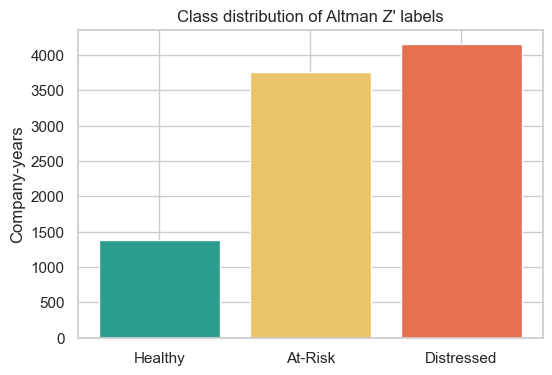

In [5]:
order = ['Healthy','At-Risk','Distressed']
palette = {'Healthy':'#2a9d8f','At-Risk':'#e9c46a','Distressed':'#e76f51'}
counts = df['label'].value_counts().reindex(order)
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=[palette[c] for c in order])
plt.ylabel('Company-years'); plt.title("Class distribution of Altman Z' labels");

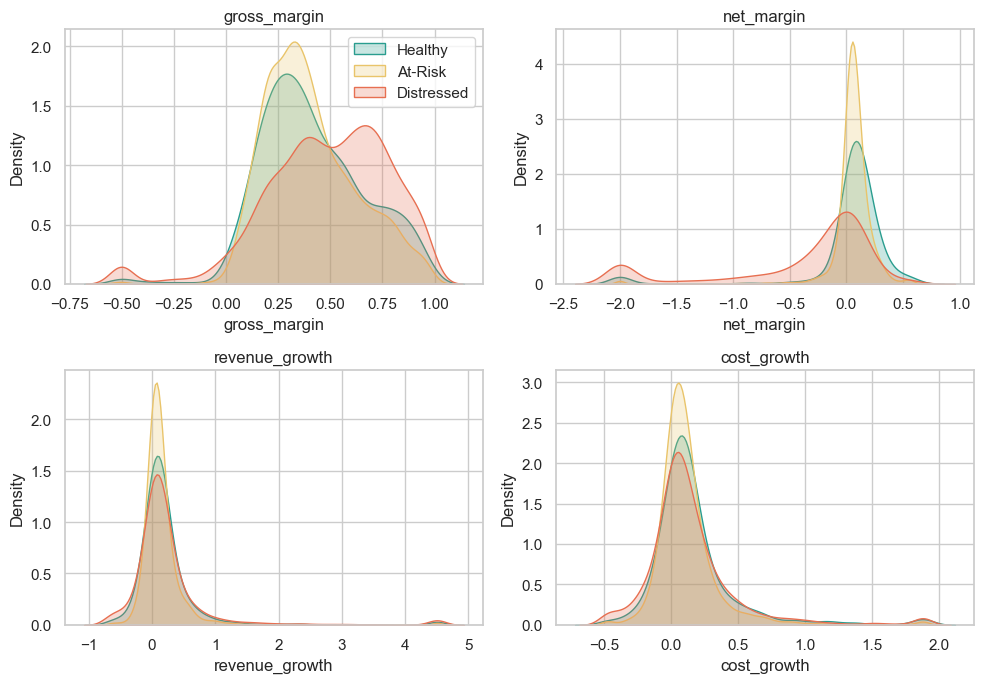

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10,7))
for ax, col in zip(axes.ravel(), ['gross_margin','net_margin','revenue_growth','cost_growth']):
    s = df[col].clip(-2,2) if col=='net_margin' else df[col]
    for lab in order:
        sns.kdeplot(s[df.label==lab], ax=ax, label=lab, color=palette[lab], fill=True, alpha=.25)
    ax.set_title(col)
axes[0,0].legend(); fig.tight_layout()

In [7]:
# Median ratio per class — sanity check that labels behave sensibly
df.groupby('label', observed=True)[['gross_margin','net_margin','revenue_growth','cost_growth']].median().round(3)

,gross_margin,net_margin,revenue_growth,cost_growth
label,,,,
Distressed,0.511,-0.099,0.104,0.081
At-Risk,0.361,0.059,0.086,0.076
Healthy,0.376,0.085,0.107,0.099


**Findings**
- Classes are imbalanced (Healthy is the minority, ~15%) → justifies the F1-macro metric chosen in the guide.
- Net margin separates the classes most cleanly (Distressed median is negative), which we expect SHAP to confirm later.
- Interesting nuance: Distressed firms have the *highest* median gross margin — many are small biotech/software firms with high gross margins but operating expenses far above revenue. Gross margin alone is therefore not a health signal, motivating the multivariate model.
- The Distressed share is high (~45%) because the Z′ distress zone is a *proxy*, not confirmed bankruptcy — small unprofitable listed firms land there without ever filing Chapter 11. This is acknowledged as a label-noise limitation in the paper.

In [8]:
# Save the hand-off deliverable
core = ['company_id','year','gross_margin','net_margin','revenue_growth','cost_growth','label']
df[core].to_csv('../data/labelled.csv', index=False)
df.to_csv('../data/labelled_full.csv', index=False)
print('Saved data/labelled.csv —', len(df), 'rows')

Saved data/labelled.csv — 9284 rows
